In [7]:
import matplotlib.pyplot as plt

In [8]:
def show_figure(vk: list[int]) -> None:
    x_points = [0] 
    y_points = [0]

    for vec in vk:
        x_points.append(x_points[-1] + vec.real)
        y_points.append(y_points[-1] + vec.imag)

    plt.figure(figsize=(5, 5))
    for i in range(len(x_points) - 1):
        plt.arrow(x_points[i], y_points[i],
                x_points[i + 1] - x_points[i], y_points[i + 1] - y_points[i],
                head_width=0.3, head_length=0.3, fc='b', ec='b')

    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')

    plt.xlim(min(x_points) - 1, max(x_points) + 1)
    plt.ylim(min(y_points) - 1, max(y_points) + 1)
    plt.grid()
    plt.title("Последовательные векторы")
    plt.show()

In [9]:
def get_shorted_vk(vk: list[int], new_len: int) -> list[float]:
    prev_len = len(vk)
    new_vk = [0] * new_len

    for i in range(prev_len):
        new_vk[int(i * new_len / prev_len)] += vk[i]

    return new_vk

In [10]:
def get_interpolated_vk(vk: list[int], new_len: int) -> list[float]:
    prev_len = len(vk)
    new_vk = [0] * new_len

    for i in range(new_len):
        index = i * prev_len / new_len
        j = int(index)
        k = index - j

        next_j = (j + 1) % prev_len

        new_vk[i] = vk[j] * (1 - k) + vk[next_j] * k
            
    return new_vk

In [11]:
def get_nsp(first_vk: list[int], second_vk: list[int]) -> list[float]:
    sum_1 = 0
    sum_2 = 0
    product = 0

    if len(second_vk) < len(first_vk):
        first_vk = get_shorted_vk(first_vk, len(second_vk))
    elif len(second_vk) > len(first_vk):
        first_vk = get_interpolated_vk(first_vk, len(second_vk))

    print("Первый вектор-контур")
    print(first_vk)

    show_figure(first_vk)

    print("Второй вектор-контур")
    print(second_vk)

    show_figure(second_vk)

    for i in range(len(first_vk)):
        elem_1 = first_vk[i]
        elem_2 = second_vk[i]

        product += (elem_1 * elem_2.conjugate())

        sum_1 += pow((abs(elem_1)), 2)
        sum_2 += pow((abs(elem_2)), 2)

    result = product / (pow(sum_1, 0.5) * pow(sum_2, 0.5))

    print("НСП фигур")
    print(result)

## 1

In [12]:
first_vk = [
        complex(2, 0),
        complex(1, 2),
        complex(1, -2),
        complex(2, 0),
        complex(-2, -1),
        complex(1, -2),
        complex(-2, 1),
        complex(-2, -1),
        complex(1, 2),
        complex(-2, 1)
        ]

second_vk = [
        complex(5, 0),
        complex(0, -4),
        complex(-5, 0),
        complex(0, 4)
        ]

Первый вектор-контур
[(4+0j), -1j, (-3-2j), (-1+3j)]


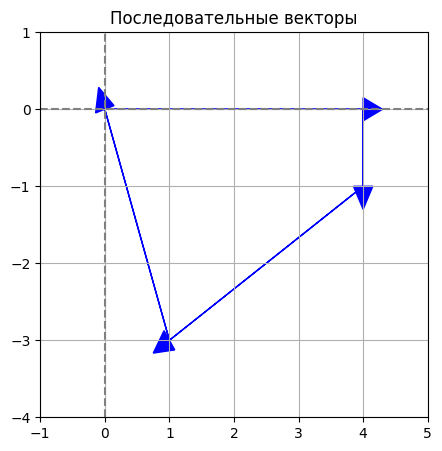

Второй вектор-контур
[(5+0j), -4j, (-5+0j), 4j]


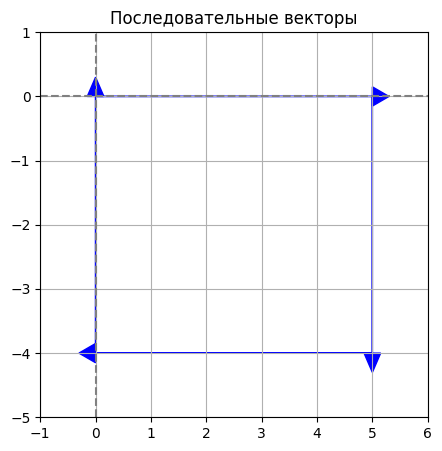

НСП фигур
(0.8904986271062121+0.24445060351935233j)


In [13]:
get_nsp(first_vk, second_vk)

## 2

In [14]:
first_vk = [
        complex(5, 0),
        complex(0, -4),
        complex(-5, 0),
        complex(0, 4)
        ]

second_vk = [
        complex(2, 0),
        complex(1, 2),
        complex(1, -2),
        complex(2, 0),
        complex(-2, -1),
        complex(1, -2),
        complex(-2, 1),
        complex(-2, -1),
        complex(1, 2),
        complex(-2, 1)
        ]

Первый вектор-контур
[(5+0j), (3-1.6j), (0.9999999999999998-3.2j), (-0.9999999999999998-3.2j), (-3.0000000000000004-1.5999999999999996j), (-5+0j), (-3.0000000000000004+1.5999999999999996j), (-1.0000000000000009+3.1999999999999993j), (1.0000000000000009+3.1999999999999993j), (3.0000000000000004+1.5999999999999996j)]


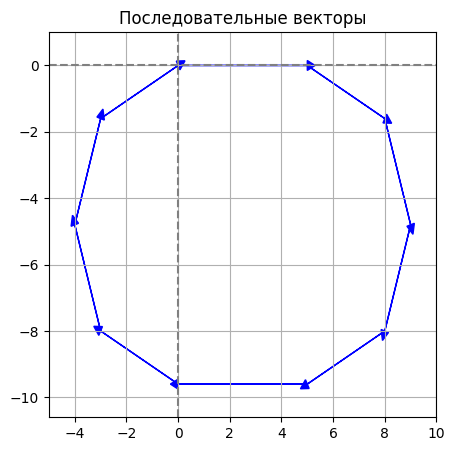

Второй вектор-контур
[(2+0j), (1+2j), (1-2j), (2+0j), (-2-1j), (1-2j), (-2+1j), (-2-1j), (1+2j), (-2+1j)]


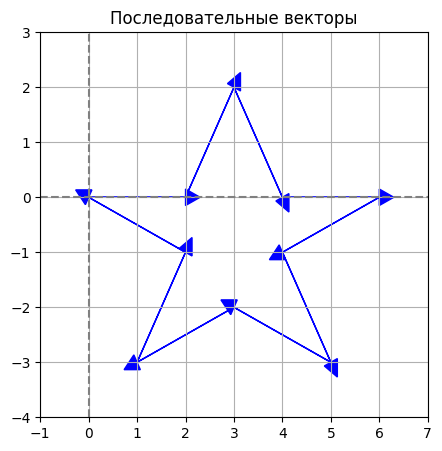

НСП фигур
(0.3303930757653559-0.45671984002858024j)


In [15]:
get_nsp(first_vk, second_vk)